#  EDA — Prédiction de fin d'alerte foudre

Ce notebook suit le fil suivant :
1. **Chargement & aperçu** — structure du dataset brut
2. **Variables brutes** — distributions, valeurs manquantes, outliers
3. **Construction des alertes** — comment les CG deviennent des alertes
4. **Features engineerées** — ce que `compute_features` calcule et pourquoi
5. **Analyse des features selon les résultats du modèle** — importance XGBoost + corrélations + comportement vis-à-vis de `y`

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f9f9f9',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
})
PALETTE = {'CG': '#1D9E75', 'IC': '#7F77DD', 'y0': '#E24B4A', 'y1': '#378ADD', 'neutral': '#888780'}

# ── Chemin à adapter ─────────────────────────────────────────────────────────
DATA_PATH = '../../data/data_train_databattle2026/segment_alerts_all_airports_train.csv'
# ─────────────────────────────────────────────────────────────────────────────
print('Imports OK')

Imports OK


---
## 1. Chargement & aperçu du dataset brut

In [4]:
df_raw = pd.read_csv(DATA_PATH, parse_dates=['date'])
df_raw = df_raw.sort_values('date').reset_index(drop=True)

print(f"Dimensions : {df_raw.shape[0]:,} lignes × {df_raw.shape[1]} colonnes")
print(f"Période    : {df_raw['date'].min().date()} → {df_raw['date'].max().date()}")
print(f"Aéroports  : {sorted(df_raw['airport'].unique())}")
print()
df_raw.head(5)

Dimensions : 507,071 lignes × 13 colonnes
Période    : 2016-01-02 → 2022-12-21
Aéroports  : ['Ajaccio', 'Bastia', 'Biarritz', 'Nantes', 'Pise']



,lightning_id,lightning_airport_id,date,lon,lat,amplitude,maxis,icloud,dist,azimuth,airport,airport_alert_id,is_last_lightning_cloud_ground
0,262043,1,2016-01-02 01:10:41+00:00,-1.4201,43.4549,-7.66,1.1,True,8.511297,97.348880,Biarritz,NaN,NaN
1,262045,3,2016-01-02 07:40:08+00:00,-1.5128,43.7366,2.26,0.3,True,29.827114,2.390385,Biarritz,NaN,NaN
2,262046,4,2016-01-02 07:40:08+00:00,-1.5011,43.7205,-79.36,0.2,False,28.084995,5.188284,Biarritz,NaN,NaN
3,262047,5,2016-01-02 07:40:08+00:00,-1.4264,43.7180,5.61,0.2,True,28.837030,21.348990,Biarritz,NaN,NaN
4,262048,6,2016-01-02 07:40:08+00:00,-1.5002,43.7204,-8.03,0.2,True,28.078755,5.393137,Biarritz,NaN,NaN


In [5]:
# ── Dtypes & valeurs manquantes ───────────────────────────────────────────────
miss = df_raw.isnull().mean().mul(100).round(1)
dtypes = df_raw.dtypes.astype(str)
summary = pd.DataFrame({'dtype': dtypes, 'missing_%': miss})
print(summary.to_string())

                                              dtype  missing_%
lightning_id                                  int64        0.0
lightning_airport_id                          int64        0.0
date                            datetime64[ns, UTC]        0.0
lon                                         float64        0.0
lat                                         float64        0.0
amplitude                                   float64        0.0
maxis                                       float64        0.0
icloud                                         bool        0.0
dist                                        float64        0.0
azimuth                                     float64        0.0
airport                                      object        0.0
airport_alert_id                            float64       88.8
is_last_lightning_cloud_ground               object       88.8


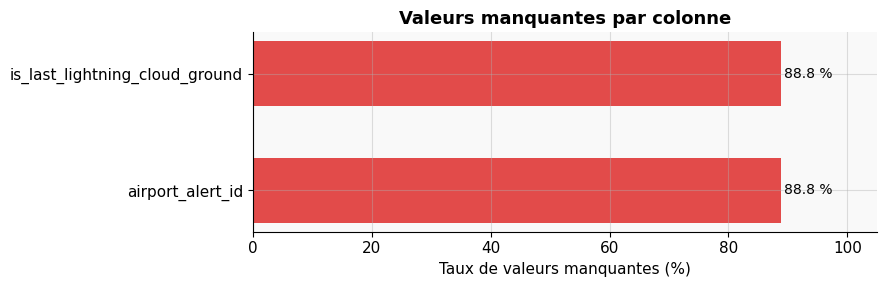


→ airport_alert_id & is_last_lightning_cloud_ground sont NaN pour les éclairs hors-alerte — c'est attendu.


In [6]:
fig, ax = plt.subplots(figsize=(9, 3))
cols_with_miss = miss[miss > 0].sort_values(ascending=True)
bars = ax.barh(cols_with_miss.index, cols_with_miss.values,
               color=['#E24B4A' if v > 50 else '#EF9F27' for v in cols_with_miss.values],
               edgecolor='none', height=0.55)
for bar, val in zip(bars, cols_with_miss.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f} %', va='center', fontsize=10)
ax.set_xlabel('Taux de valeurs manquantes (%)')
ax.set_title('Valeurs manquantes par colonne')
ax.set_xlim(0, 105)
plt.tight_layout()
plt.show()

print("\n→ airport_alert_id & is_last_lightning_cloud_ground sont NaN pour les éclairs hors-alerte — c'est attendu.")

In [7]:
# Filtrage Pise 2016 IC (comme dans le modèle)
mask_pise = (df_raw['airport'] == 'Pise') & (df_raw['date'].dt.year == 2016) & (df_raw['icloud'] == True)
n_pise = mask_pise.sum()
print(f"Éclairs Pise 2016 IC à filtrer : {n_pise:,}")
df = df_raw[~mask_pise].reset_index(drop=True)
print(f"Dataset après filtrage : {len(df):,} lignes")

Éclairs Pise 2016 IC à filtrer : 19,404
Dataset après filtrage : 487,667 lignes


---
## 2. Distributions des variables brutes

CG : 128,992 (26.5 %)   IC : 358,675 (73.5 %)


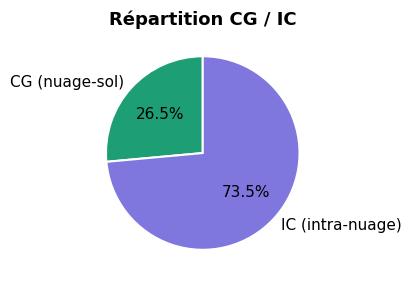

In [8]:
# ── 2.1 Split CG / IC ─────────────────────────────────────────────────────────
cg = df[df['icloud'] == False]
ic = df[df['icloud'] == True]
print(f"CG : {len(cg):,} ({100*len(cg)/len(df):.1f} %)   IC : {len(ic):,} ({100*len(ic)/len(df):.1f} %)")

fig, ax = plt.subplots(figsize=(4, 4))
ax.pie([len(cg), len(ic)], labels=['CG (nuage-sol)', 'IC (intra-nuage)'],
       colors=[PALETTE['CG'], PALETTE['IC']], autopct='%1.1f%%',
       startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax.set_title('Répartition CG / IC')
ax.set_facecolor('white')
plt.tight_layout()
plt.show()

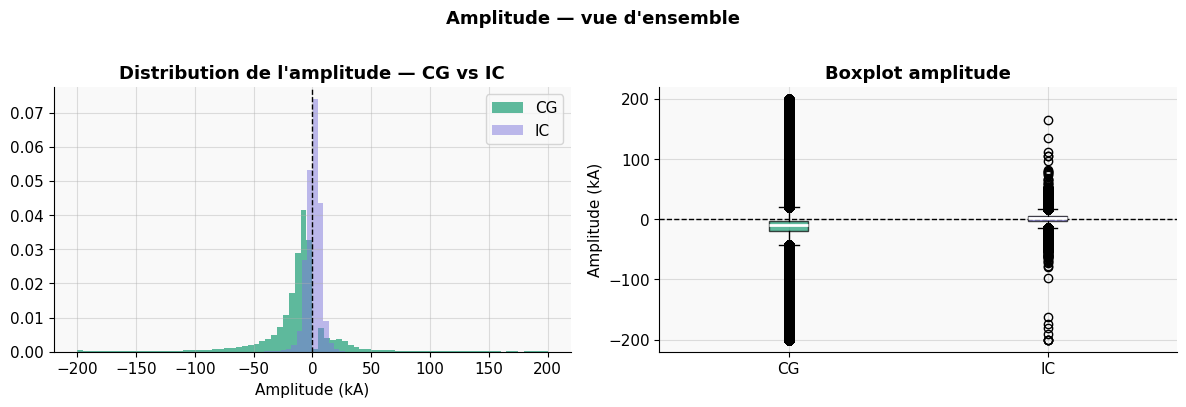


Statistiques amplitude CG :
count    128992.00
mean        -11.88
std          36.85
min        -425.02
25%         -18.97
50%          -9.07
75%          -3.31
max         497.00

Statistiques amplitude IC :
count    358675.00
mean          1.06
std           6.44
min        -429.50
25%          -3.00
50%           2.39
75%           4.88
max         164.14


In [9]:
# ── 2.2 Amplitude ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogramme complet
axes[0].hist(cg['amplitude'].clip(-200, 200), bins=80,
             color=PALETTE['CG'], alpha=0.7, label='CG', density=True)
axes[0].hist(ic['amplitude'].clip(-200, 200), bins=80,
             color=PALETTE['IC'], alpha=0.5, label='IC', density=True)
axes[0].axvline(0, color='black', lw=1, ls='--')
axes[0].set_xlabel('Amplitude (kA)')
axes[0].set_title('Distribution de l\'amplitude — CG vs IC')
axes[0].legend()

# Boxplot par type
data_box = [cg['amplitude'].clip(-200, 200).dropna(),
            ic['amplitude'].clip(-200, 200).dropna()]
bp = axes[1].boxplot(data_box, labels=['CG', 'IC'], patch_artist=True,
                     medianprops={'color': 'white', 'linewidth': 2})
for patch, color in zip(bp['boxes'], [PALETTE['CG'], PALETTE['IC']]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].axhline(0, color='black', lw=1, ls='--')
axes[1].set_ylabel('Amplitude (kA)')
axes[1].set_title('Boxplot amplitude')

plt.suptitle('Amplitude — vue d\'ensemble', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('\nStatistiques amplitude CG :')
print(cg['amplitude'].describe().round(2).to_string())
print('\nStatistiques amplitude IC :')
print(ic['amplitude'].describe().round(2).to_string())

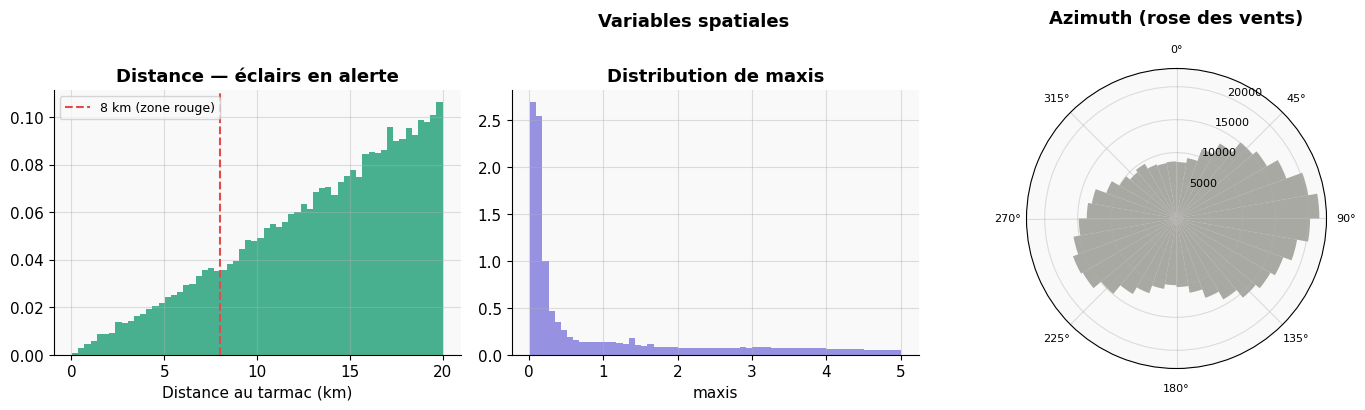

In [10]:
# ── 2.3 Distance, maxis, azimuth ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Distance
in_alert = df[df['airport_alert_id'].notna()]
axes[0].hist(in_alert['dist'].dropna(), bins=60, color=PALETTE['CG'],
             alpha=0.8, edgecolor='none', density=True)
axes[0].axvline(8, color='#E24B4A', lw=1.5, ls='--', label='8 km (zone rouge)')
axes[0].set_xlabel('Distance au tarmac (km)')
axes[0].set_title('Distance — éclairs en alerte')
axes[0].legend(fontsize=9)

# Maxis
axes[1].hist(df['maxis'].clip(0, 5).dropna(), bins=60,
             color=PALETTE['IC'], alpha=0.8, edgecolor='none', density=True)
axes[1].set_xlabel('maxis')
axes[1].set_title('Distribution de maxis')

# Azimuth
az_counts, az_bins = np.histogram(df['azimuth'].dropna() % 360, bins=36)
theta = np.deg2rad((az_bins[:-1] + az_bins[1:]) / 2)
ax_polar = fig.add_axes([0.72, 0.12, 0.25, 0.75], polar=True)
ax_polar.bar(theta, az_counts, width=np.deg2rad(10),
             color=PALETTE['neutral'], alpha=0.7, edgecolor='none')
ax_polar.set_title('Azimuth (rose des vents)', pad=15)
ax_polar.set_theta_zero_location('N')
ax_polar.set_theta_direction(-1)
ax_polar.tick_params(labelsize=8)
axes[2].remove()  # remplacé par le polar

plt.suptitle('Variables spatiales', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [11]:
# ── 2.4 Statistiques descriptives complètes ───────────────────────────────────
num_cols = ['amplitude', 'dist', 'maxis', 'azimuth']
df[num_cols].describe().round(3)

,amplitude,dist,maxis,azimuth
count,487667.000,487667.000,487667.000,487667.000
mean,-2.362,20.243,1.020,168.503
std,20.547,6.937,1.351,97.443
min,-429.500,0.037,0.016,0.000
25%,-5.620,15.410,0.106,85.019
50%,-1.600,21.435,0.239,156.477
75%,4.530,26.109,1.532,250.891
max,497.000,30.000,6.900,359.979


---
## 3. Temporalité — saisonnalité & cycle diurne

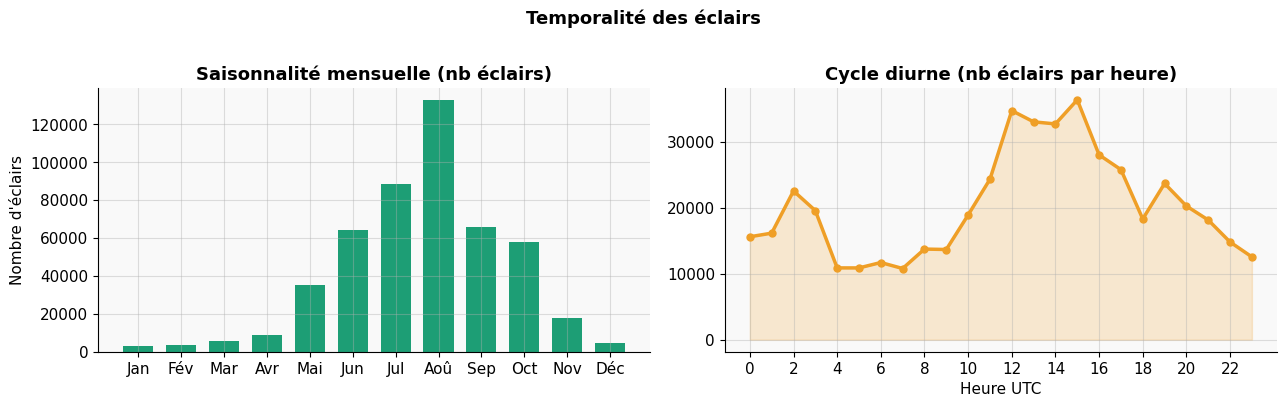

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Saisonnalité mensuelle
monthly = df.groupby(df['date'].dt.month).size()
axes[0].bar(monthly.index, monthly.values, color=PALETTE['CG'],
            edgecolor='none', width=0.7)
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(['Jan','Fév','Mar','Avr','Mai','Jun',
                          'Jul','Aoû','Sep','Oct','Nov','Déc'])
axes[0].set_title('Saisonnalité mensuelle (nb éclairs)')
axes[0].set_ylabel('Nombre d\'éclairs')

# Cycle diurne
hourly = df.groupby(df['date'].dt.hour).size()
axes[1].plot(hourly.index, hourly.values,
             color='#EF9F27', lw=2.5, marker='o', ms=5)
axes[1].fill_between(hourly.index, hourly.values, alpha=0.2, color='#EF9F27')
axes[1].set_xlabel('Heure UTC')
axes[1].set_title('Cycle diurne (nb éclairs par heure)')
axes[1].set_xticks(range(0, 24, 2))

plt.suptitle('Temporalité des éclairs', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

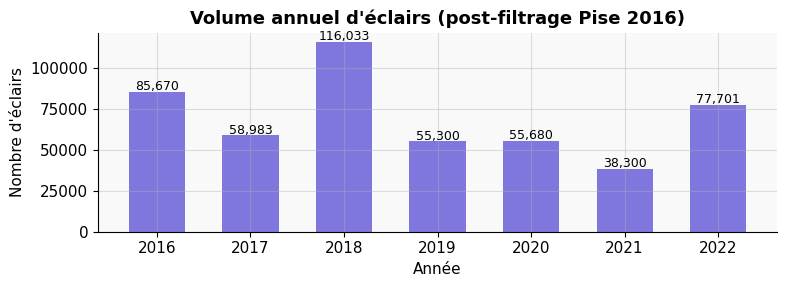

In [13]:
# ── Évolution annuelle ────────────────────────────────────────────────────────
yearly = df.groupby(df['date'].dt.year).size()
fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(yearly.index, yearly.values, color=PALETTE['IC'], edgecolor='none', width=0.6)
ax.set_title('Volume annuel d\'éclairs (post-filtrage Pise 2016)')
ax.set_ylabel('Nombre d\'éclairs')
ax.set_xlabel('Année')
for x, y in zip(yearly.index, yearly.values):
    ax.text(x, y + yearly.max()*0.01, f'{y:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## 4. Construction des alertes

Rappel : une **alerte** = groupe d'éclairs CG associé à un `airport_alert_id`. La durée est calculée de `start_time` (premier CG) jusqu'à `end_time + 30 min` (règle opérationnelle).

In [14]:
def build_alerts_from_cg(df, end_delay_min=30):
    cg_strikes = df[(df['icloud'] == False) & (df['airport_alert_id'].notna())].copy()
    cg_strikes['airport_alert_id'] = cg_strikes['airport_alert_id'].astype(int)
    alerts = []
    for (airport, alert_id), group in cg_strikes.groupby(['airport', 'airport_alert_id']):
        group = group.sort_values('date')
        start_time = group['date'].iloc[0]
        last_cg = group[group['is_last_lightning_cloud_ground'] == True]
        end_time = last_cg['date'].iloc[0] if len(last_cg) > 0 else group['date'].iloc[-1]
        buffer = pd.Timedelta(minutes=5)
        mask = ((df['airport'] == airport) &
                (df['date'] >= start_time - buffer) &
                (df['date'] <= end_time + buffer))
        all_in_alert = df[mask]
        alerts.append({
            'airport':            airport,
            'airport_alert_id':   alert_id,
            'start_time':         start_time,
            'end_time':           end_time,
            'alert_end_official': end_time + pd.Timedelta(minutes=end_delay_min),
            'lightning_count':    len(all_in_alert),
            'cg_count':           len(group),
        })
    return pd.DataFrame(alerts)

alerts = build_alerts_from_cg(df)
print(f"Alertes totales : {len(alerts):,}")
alerts.head(5)

Alertes totales : 2,627


,airport,airport_alert_id,start_time,end_time,alert_end_official,lightning_count,cg_count
0,Ajaccio,1,2016-01-02 21:22:53+00:00,2016-01-02 21:28:54+00:00,2016-01-02 21:58:54+00:00,8,5
1,Ajaccio,2,2016-01-12 06:37:45+00:00,2016-01-12 06:37:45+00:00,2016-01-12 07:07:45+00:00,6,1
2,Ajaccio,3,2016-01-12 07:25:37+00:00,2016-01-12 07:25:37+00:00,2016-01-12 07:55:37+00:00,2,1
3,Ajaccio,4,2016-02-07 14:05:14+00:00,2016-02-07 14:05:14+00:00,2016-02-07 14:35:14+00:00,4,1
4,Ajaccio,5,2016-02-07 14:35:39+00:00,2016-02-07 14:35:39+00:00,2016-02-07 15:05:39+00:00,2,1


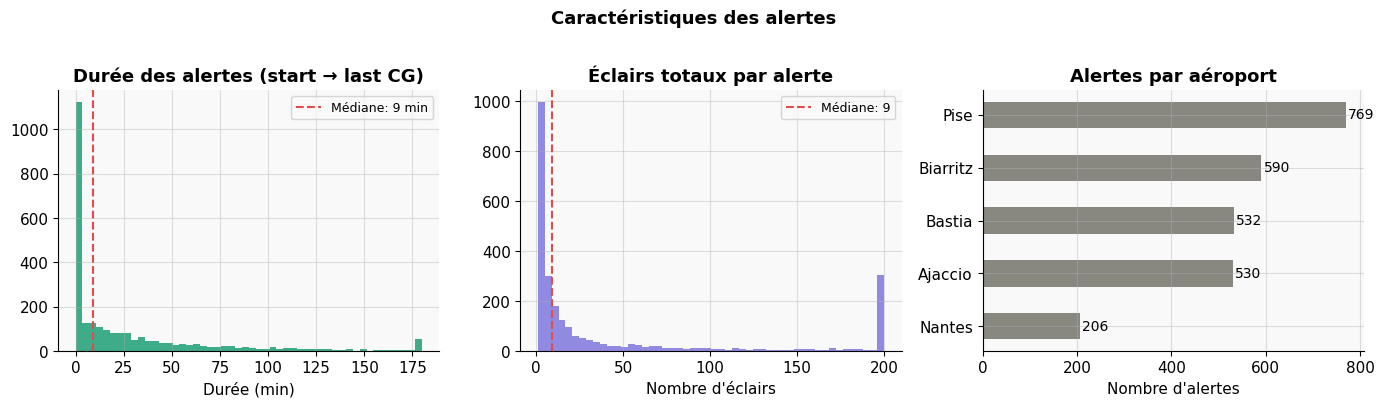

       duration_min  lightning_count  cg_count
count        2627.0           2627.0    2627.0
mean           29.9            161.4      21.5
std            50.3            718.8      85.6
min             0.0              1.0       1.0
25%             0.0              2.0       1.0
50%             8.9              9.0       3.0
75%            38.6             50.5      10.0
max           578.7          12167.0    2405.0


In [15]:
alerts['duration_min'] = (alerts['end_time'] - alerts['start_time']).dt.total_seconds() / 60
alerts['duration_official_min'] = (alerts['alert_end_official'] - alerts['start_time']).dt.total_seconds() / 60

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Durée des alertes
axes[0].hist(alerts['duration_min'].clip(0, 180), bins=50,
             color=PALETTE['CG'], edgecolor='none', alpha=0.85)
axes[0].axvline(alerts['duration_min'].median(), color='#E24B4A',
                lw=1.5, ls='--', label=f"Médiane: {alerts['duration_min'].median():.0f} min")
axes[0].set_xlabel('Durée (min)')
axes[0].set_title('Durée des alertes (start → last CG)')
axes[0].legend(fontsize=9)

# Nombre d'éclairs par alerte
axes[1].hist(alerts['lightning_count'].clip(0, 200), bins=50,
             color=PALETTE['IC'], edgecolor='none', alpha=0.85)
axes[1].axvline(alerts['lightning_count'].median(), color='#E24B4A',
                lw=1.5, ls='--', label=f"Médiane: {alerts['lightning_count'].median():.0f}")
axes[1].set_xlabel('Nombre d\'éclairs')
axes[1].set_title('Éclairs totaux par alerte')
axes[1].legend(fontsize=9)

# Alertes par aéroport
by_airport = alerts.groupby('airport').size().sort_values()
axes[2].barh(by_airport.index, by_airport.values,
             color=PALETTE['neutral'], edgecolor='none', height=0.5)
for i, (idx, val) in enumerate(by_airport.items()):
    axes[2].text(val + 5, i, str(val), va='center', fontsize=10)
axes[2].set_xlabel('Nombre d\'alertes')
axes[2].set_title('Alertes par aéroport')

plt.suptitle('Caractéristiques des alertes', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(alerts[['duration_min', 'lightning_count', 'cg_count']].describe().round(1).to_string())

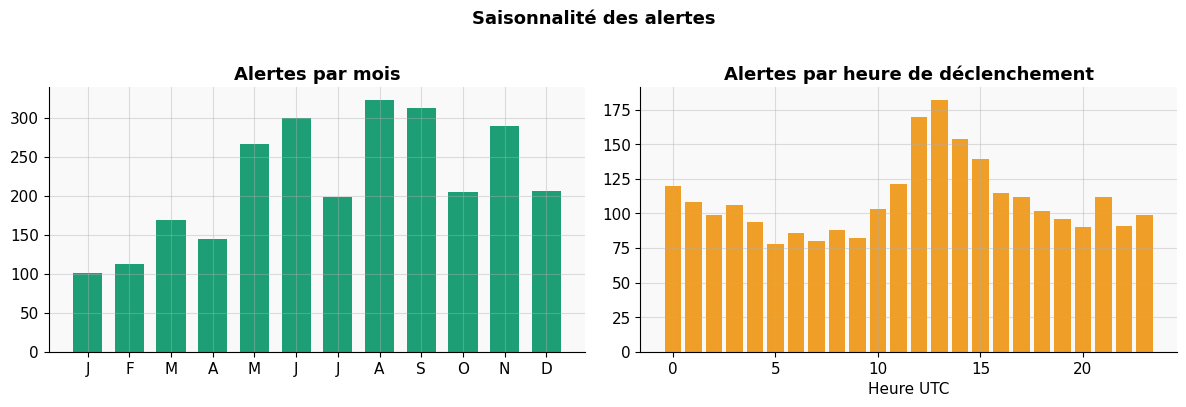

In [16]:
# ── Saisonnalité des alertes ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
alert_month = alerts.groupby(alerts['start_time'].dt.month).size()
axes[0].bar(alert_month.index, alert_month.values, color=PALETTE['CG'],
            edgecolor='none', width=0.7)
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
axes[0].set_title('Alertes par mois')

alert_hour = alerts.groupby(alerts['start_time'].dt.hour).size()
axes[1].bar(alert_hour.index, alert_hour.values, color='#EF9F27',
            edgecolor='none', width=0.8)
axes[1].set_title('Alertes par heure de déclenchement')
axes[1].set_xlabel('Heure UTC')

plt.suptitle('Saisonnalité des alertes', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 5. Features engineerées — catalogue et distributions

Le pipeline `compute_features` génère **5 familles** de features à partir des éclairs passés :

| Famille | Features | Signal attendu |
|---|---|---|
| **Temporelles de récence** | `time_since_last`, `time_since_last_cg`, `time_since_last_ic`, `time_since_peak` | Silence → fin probable |
| **Comptages / taux** | `strike_count_{5,10,30}min`, `rate_{5,10,30}min` | Activité décroissante |
| **Inter-arrivées** | `std_interarrival`, `max_interarrival`, `deceleration` | Grand max → pause déjà vue |
| **Spatiales** | `mean_dist`, `trend_dist`, `dist_recent_vs_mean`, `angular_spread`, `azimuth_concentration` | Orage qui s'éloigne |
| **Physiques** | `prop_ic`, `mean_amplitude`, `std_amplitude`, `amplitude_trend`, `ic_ratio_trend` | Intensité qui faiblit |
| **Cycliques** | `month_sin/cos`, `hour_sin/cos`, `minute_of_day_sin/cos` | Contexte saisonnier/diurne |

In [17]:
# ── Reconstruction inline du dataset ML ──────────────────────────────────────
# On réutilise df (déjà filtré) et alerts (déjà construits en section 4).
# compute_features + generate_samples_for_alert sont redéfinis ici pour que
# cette section soit autonome.

from tqdm.auto import tqdm

HORIZON_MIN = 30

def compute_features(past_strikes, current_time, airport):
    feat = {'airport': airport}
    feat['month']             = current_time.month
    feat['hour']              = current_time.hour
    feat['month_sin']         = np.sin(2 * np.pi * current_time.month / 12)
    feat['month_cos']         = np.cos(2 * np.pi * current_time.month / 12)
    feat['hour_sin']          = np.sin(2 * np.pi * current_time.hour / 24)
    feat['hour_cos']          = np.cos(2 * np.pi * current_time.hour / 24)
    mins = current_time.hour * 60 + current_time.minute
    feat['minute_of_day_sin'] = np.sin(2 * np.pi * mins / 1440)
    feat['minute_of_day_cos'] = np.cos(2 * np.pi * mins / 1440)

    nan_feats  = ['time_since_last','time_since_last_cg','time_since_last_ic',
                  'time_since_first','time_since_peak','std_interarrival','max_interarrival',
                  'mean_dist','trend_dist','dist_recent_vs_mean','angular_spread',
                  'azimuth_concentration','prop_ic','mean_amplitude','std_amplitude',
                  'amplitude_trend','ic_ratio_trend','rate_ratio_5_30','deceleration']
    zero_feats = ['strike_count_5min','strike_count_10min','strike_count_30min',
                  'rate_5min','rate_10min','rate_30min']

    if len(past_strikes) == 0:
        for f in nan_feats:  feat[f] = np.nan
        for f in zero_feats: feat[f] = 0
        return feat

    last = past_strikes.iloc[-1]
    feat['time_since_last'] = (current_time - last['date']).total_seconds() / 60.0
    last_cg = past_strikes[past_strikes['icloud'] == False]
    feat['time_since_last_cg'] = (
        (current_time - last_cg.iloc[-1]['date']).total_seconds() / 60.0
        if len(last_cg) > 0 else np.nan)
    last_ic = past_strikes[past_strikes['icloud'] == True]
    feat['time_since_last_ic'] = (
        (current_time - last_ic.iloc[-1]['date']).total_seconds() / 60.0
        if len(last_ic) > 0 else np.nan)
    feat['time_since_first'] = (current_time - past_strikes.iloc[0]['date']).total_seconds() / 60.0
    try:
        tmp = past_strikes.set_index('date').resample('5min').size()
        feat['time_since_peak'] = (
            (current_time - tmp.idxmax()).total_seconds() / 60.0 if len(tmp) > 0 else np.nan)
    except Exception:
        feat['time_since_peak'] = np.nan

    counts = {}
    for w in [5, 10, 30]:
        mask = past_strikes['date'] >= current_time - pd.Timedelta(minutes=w)
        cnt  = int(mask.sum())
        feat[f'strike_count_{w}min'] = cnt
        feat[f'rate_{w}min']         = cnt / w
        counts[w] = cnt
    r1 = counts[5] / 5
    r2 = (counts[10] - counts[5]) / 5
    r3 = (counts[30] - counts[10]) / 20
    feat['deceleration']   = np.polyfit([0,1,2], [r1,r2,r3], 1)[0]
    feat['rate_ratio_5_30'] = counts[5] / (counts[30] + 1e-6)

    if len(past_strikes) >= 2:
        intervals = past_strikes['date'].diff().dt.total_seconds().dropna() / 60.0
        feat['std_interarrival'] = intervals.std()
        feat['max_interarrival'] = intervals.max()
    else:
        feat['std_interarrival'] = np.nan
        feat['max_interarrival'] = np.nan

    feat['mean_dist'] = past_strikes['dist'].mean()
    recent = past_strikes.tail(min(5, len(past_strikes)))
    feat['trend_dist'] = (
        np.polyfit(np.arange(len(recent)), recent['dist'].values, 1)[0]
        if len(recent) >= 2 else 0)
    feat['dist_recent_vs_mean'] = recent['dist'].mean() - past_strikes['dist'].mean()
    feat['angular_spread']      = past_strikes['azimuth'].std()
    feat['azimuth_concentration'] = float(np.sqrt(
        np.cos(np.deg2rad(past_strikes['azimuth'])).mean()**2 +
        np.sin(np.deg2rad(past_strikes['azimuth'])).mean()**2))

    feat['prop_ic']        = past_strikes['icloud'].mean()
    feat['mean_amplitude'] = past_strikes['amplitude'].mean()
    feat['std_amplitude']  = past_strikes['amplitude'].std()
    recent10 = past_strikes.tail(min(10, len(past_strikes)))
    feat['amplitude_trend'] = (
        np.polyfit(np.arange(len(recent10)), recent10['amplitude'].values, 1)[0]
        if len(recent10) >= 2 else 0)
    recent_ic = past_strikes.tail(10)['icloud'].mean()
    global_ic = past_strikes['icloud'].mean()
    feat['ic_ratio_trend'] = recent_ic / (global_ic + 1e-6)
    return feat


def get_strikes_for_alert(df_full, airport, start_time, end_time, buffer_min=5):
    start = start_time - pd.Timedelta(minutes=buffer_min)
    end   = end_time   + pd.Timedelta(minutes=buffer_min)
    mask  = (df_full['airport'] == airport) & (df_full['date'] >= start) & (df_full['date'] <= end)
    return df_full[mask].copy().sort_values('date')


def generate_samples_for_alert(alert_row, df_full, horizon_min=30, freq_min=1, buffer_min=5):
    airport      = alert_row['airport']
    start        = alert_row['start_time']
    end_cg       = alert_row['end_time']
    end_official = alert_row['alert_end_official']
    strikes = get_strikes_for_alert(
        df_full, airport, start, end_cg,
        buffer_min=buffer_min + horizon_min)
    samples = []
    for t in pd.date_range(start, end_official, freq=f'{freq_min}min'):
        past   = strikes[strikes['date'] < t]
        future = strikes[(strikes['date'] >= t) &
                         (strikes['date'] <  t + pd.Timedelta(minutes=horizon_min))]
        feats = compute_features(past, t, airport)
        feats['time']             = t
        feats['y']                = 1 if len(future) > 0 else 0
        feats['airport_alert_id'] = alert_row['airport_alert_id']
        samples.append(feats)
    return pd.DataFrame(samples)


print('Génération du dataset ML (peut prendre quelques minutes)...')
all_samples = []
for _, row in tqdm(alerts.iterrows(), total=len(alerts)):
    all_samples.append(
        generate_samples_for_alert(row, df, horizon_min=HORIZON_MIN))
ds = pd.concat(all_samples, ignore_index=True)
print(f'Dataset ML prêt : {ds.shape}')

Génération du dataset ML (peut prendre quelques minutes)...


100%|██████████| 2627/2627 [05:52<00:00,  7.45it/s]


Dataset ML prêt : (159161, 37)


In [18]:
if ds is not None:
    feature_cols = [c for c in ds.columns if c not in ['time', 'y', 'airport', 'airport_alert_id']]
    print(f"Features : {len(feature_cols)}")
    print(feature_cols)
    print(f"\nTarget y — distribution :")
    print(ds['y'].value_counts(normalize=True).round(3).to_string())
    print(f"\nValeurs manquantes dans les features (% de lignes) :")
    miss_feat = ds[feature_cols].isnull().mean().mul(100).round(1)
    print(miss_feat[miss_feat > 0].sort_values(ascending=False).to_string())

Features : 33
['month', 'hour', 'month_sin', 'month_cos', 'hour_sin', 'hour_cos', 'minute_of_day_sin', 'minute_of_day_cos', 'time_since_last', 'time_since_last_cg', 'time_since_last_ic', 'time_since_first', 'time_since_peak', 'std_interarrival', 'max_interarrival', 'mean_dist', 'trend_dist', 'dist_recent_vs_mean', 'angular_spread', 'azimuth_concentration', 'prop_ic', 'mean_amplitude', 'std_amplitude', 'amplitude_trend', 'ic_ratio_trend', 'rate_ratio_5_30', 'deceleration', 'strike_count_5min', 'strike_count_10min', 'strike_count_30min', 'rate_5min', 'rate_10min', 'rate_30min']

Target y — distribution :
y
1    0.738
0    0.262

Valeurs manquantes dans les features (% de lignes) :
time_since_last_ic       17.7
std_interarrival         11.1
max_interarrival          7.0
std_amplitude             7.0
angular_spread            7.0
time_since_last_cg        0.8
time_since_last           0.5
prop_ic                   0.5
rate_ratio_5_30           0.5
ic_ratio_trend            0.5
amplitude_tr

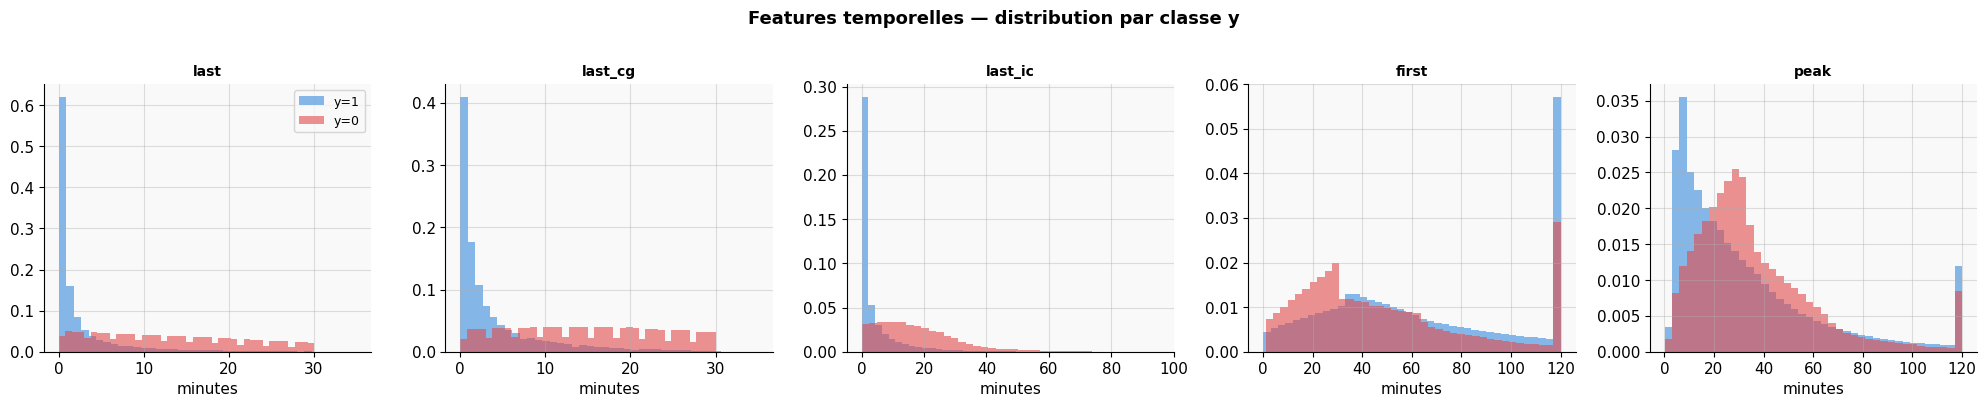

→ La séparation entre y=0 et y=1 est forte : les fins d'alerte (y=0) ont des temps since_last bien plus élevés.


In [19]:
if ds is not None:
    # ── Distributions des features temporelles clés ────────────────────────────
    temporal_feats = ['time_since_last', 'time_since_last_cg', 'time_since_last_ic',
                      'time_since_first', 'time_since_peak']
    temporal_feats = [f for f in temporal_feats if f in ds.columns]

    fig, axes = plt.subplots(1, len(temporal_feats), figsize=(4*len(temporal_feats), 4))
    if len(temporal_feats) == 1:
        axes = [axes]

    for ax, feat in zip(axes, temporal_feats):
        data_y0 = ds[ds['y'] == 0][feat].clip(0, 120).dropna()
        data_y1 = ds[ds['y'] == 1][feat].clip(0, 120).dropna()
        ax.hist(data_y1, bins=40, color=PALETTE['y1'], alpha=0.6,
                density=True, label='y=1')
        ax.hist(data_y0, bins=40, color=PALETTE['y0'], alpha=0.6,
                density=True, label='y=0')
        ax.set_title(feat.replace('time_since_', ''), fontsize=10)
        ax.set_xlabel('minutes')
        if ax == axes[0]:
            ax.legend(fontsize=9)

    plt.suptitle('Features temporelles — distribution par classe y', fontsize=13,
                 fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()
    print("→ La séparation entre y=0 et y=1 est forte : les fins d'alerte (y=0) ont des temps since_last bien plus élevés.")

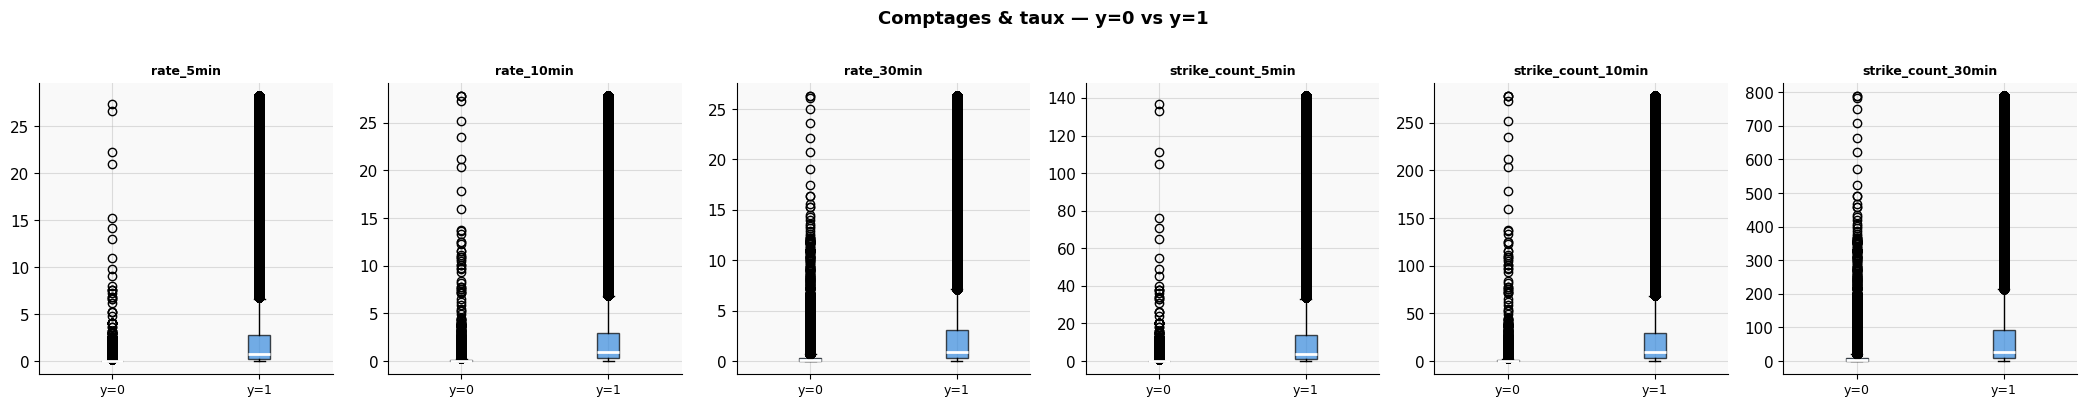

→ y=0 (fin d'alerte) a systématiquement des taux plus faibles — c'est le signal principal.


In [20]:
if ds is not None:
    # ── Taux & comptages ───────────────────────────────────────────────────────
    rate_feats = ['rate_5min', 'rate_10min', 'rate_30min',
                  'strike_count_5min', 'strike_count_10min', 'strike_count_30min']
    rate_feats = [f for f in rate_feats if f in ds.columns]

    n = len(rate_feats)
    fig, axes = plt.subplots(1, n, figsize=(3.5*n, 4))
    if n == 1:
        axes = [axes]

    for ax, feat in zip(axes, rate_feats):
        ax.boxplot(
            [ds[ds['y']==0][feat].clip(0, ds[feat].quantile(0.98)).dropna(),
             ds[ds['y']==1][feat].clip(0, ds[feat].quantile(0.98)).dropna()],
            labels=['y=0', 'y=1'],
            patch_artist=True,
            medianprops={'color': 'white', 'linewidth': 2},
            boxprops={'facecolor': PALETTE['y1'], 'alpha': 0.7}
        )
        ax.set_title(feat, fontsize=9)
        ax.tick_params(axis='x', labelsize=9)

    plt.suptitle('Comptages & taux — y=0 vs y=1', fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()
    print("→ y=0 (fin d'alerte) a systématiquement des taux plus faibles — c'est le signal principal.")

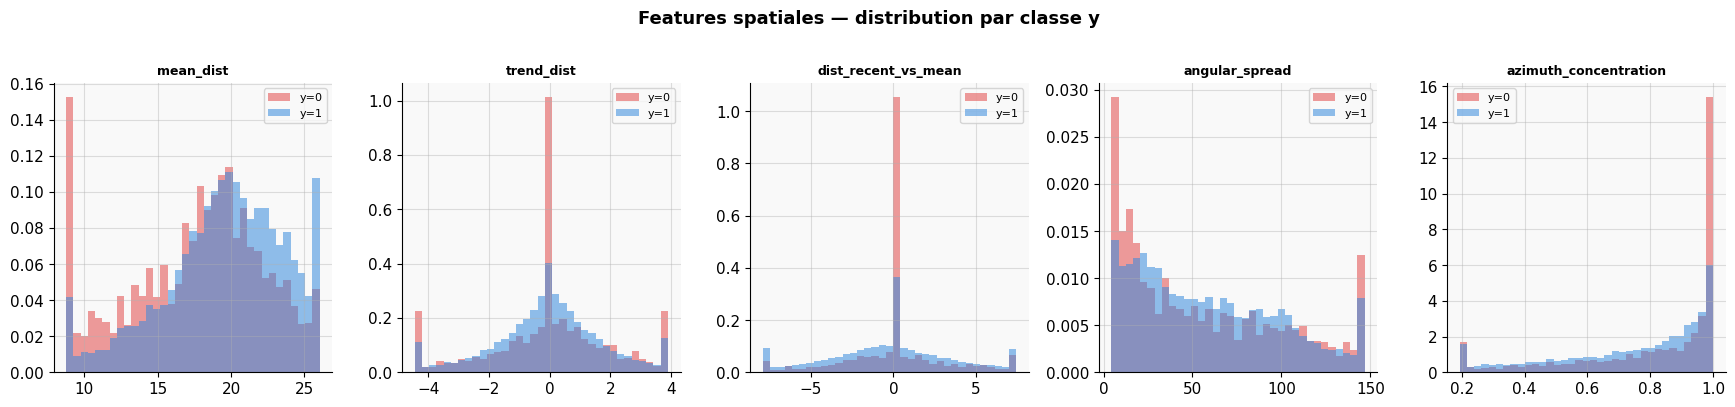

→ dist_recent_vs_mean > 0 (éclairs récents plus loin que la moyenne) → signal de fin.


In [21]:
if ds is not None:
    # ── Features spatiales ─────────────────────────────────────────────────────
    spatial_feats = ['mean_dist', 'trend_dist', 'dist_recent_vs_mean',
                     'angular_spread', 'azimuth_concentration']
    spatial_feats = [f for f in spatial_feats if f in ds.columns]

    n = len(spatial_feats)
    fig, axes = plt.subplots(1, n, figsize=(3.5*n, 4))
    if n == 1:
        axes = [axes]

    for ax, feat in zip(axes, spatial_feats):
        clip_val = ds[feat].quantile(0.97)
        clip_min = ds[feat].quantile(0.03)
        for cls, color, lbl in [(0, PALETTE['y0'], 'y=0'), (1, PALETTE['y1'], 'y=1')]:
            vals = ds[ds['y'] == cls][feat].clip(clip_min, clip_val).dropna()
            ax.hist(vals, bins=35, color=color, alpha=0.55, density=True, label=lbl)
        ax.set_title(feat, fontsize=9)
        ax.legend(fontsize=8)

    plt.suptitle('Features spatiales — distribution par classe y', fontsize=13,
                 fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()
    print("→ dist_recent_vs_mean > 0 (éclairs récents plus loin que la moyenne) → signal de fin.")

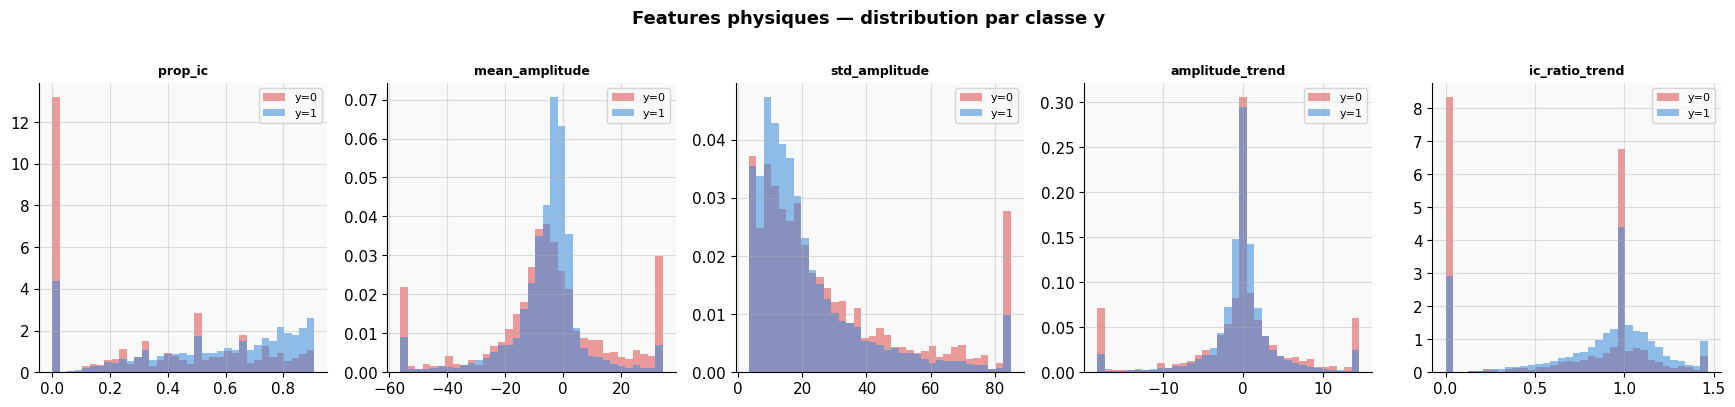

In [22]:
if ds is not None:
    # ── Features physiques ─────────────────────────────────────────────────────
    phys_feats = ['prop_ic', 'mean_amplitude', 'std_amplitude',
                  'amplitude_trend', 'ic_ratio_trend']
    phys_feats = [f for f in phys_feats if f in ds.columns]

    n = len(phys_feats)
    fig, axes = plt.subplots(1, n, figsize=(3.5*n, 4))
    if n == 1:
        axes = [axes]

    for ax, feat in zip(axes, phys_feats):
        clip_val = ds[feat].quantile(0.97)
        clip_min = ds[feat].quantile(0.03)
        for cls, color, lbl in [(0, PALETTE['y0'], 'y=0'), (1, PALETTE['y1'], 'y=1')]:
            vals = ds[ds['y'] == cls][feat].clip(clip_min, clip_val).dropna()
            ax.hist(vals, bins=35, color=color, alpha=0.55, density=True, label=lbl)
        ax.set_title(feat, fontsize=9)
        ax.legend(fontsize=8)

    plt.suptitle('Features physiques — distribution par classe y', fontsize=13,
                 fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

---
## 6. Analyse des features en fonction des résultats du modèle

Cette section relie les features à la performance XGBoost :
- Importance par gain (depuis le modèle sauvegardé)
- Corrélations entre features
- Évolution temporelle des features au fil d'une alerte
- Analyse du trade-off seuil / gain opérationnel

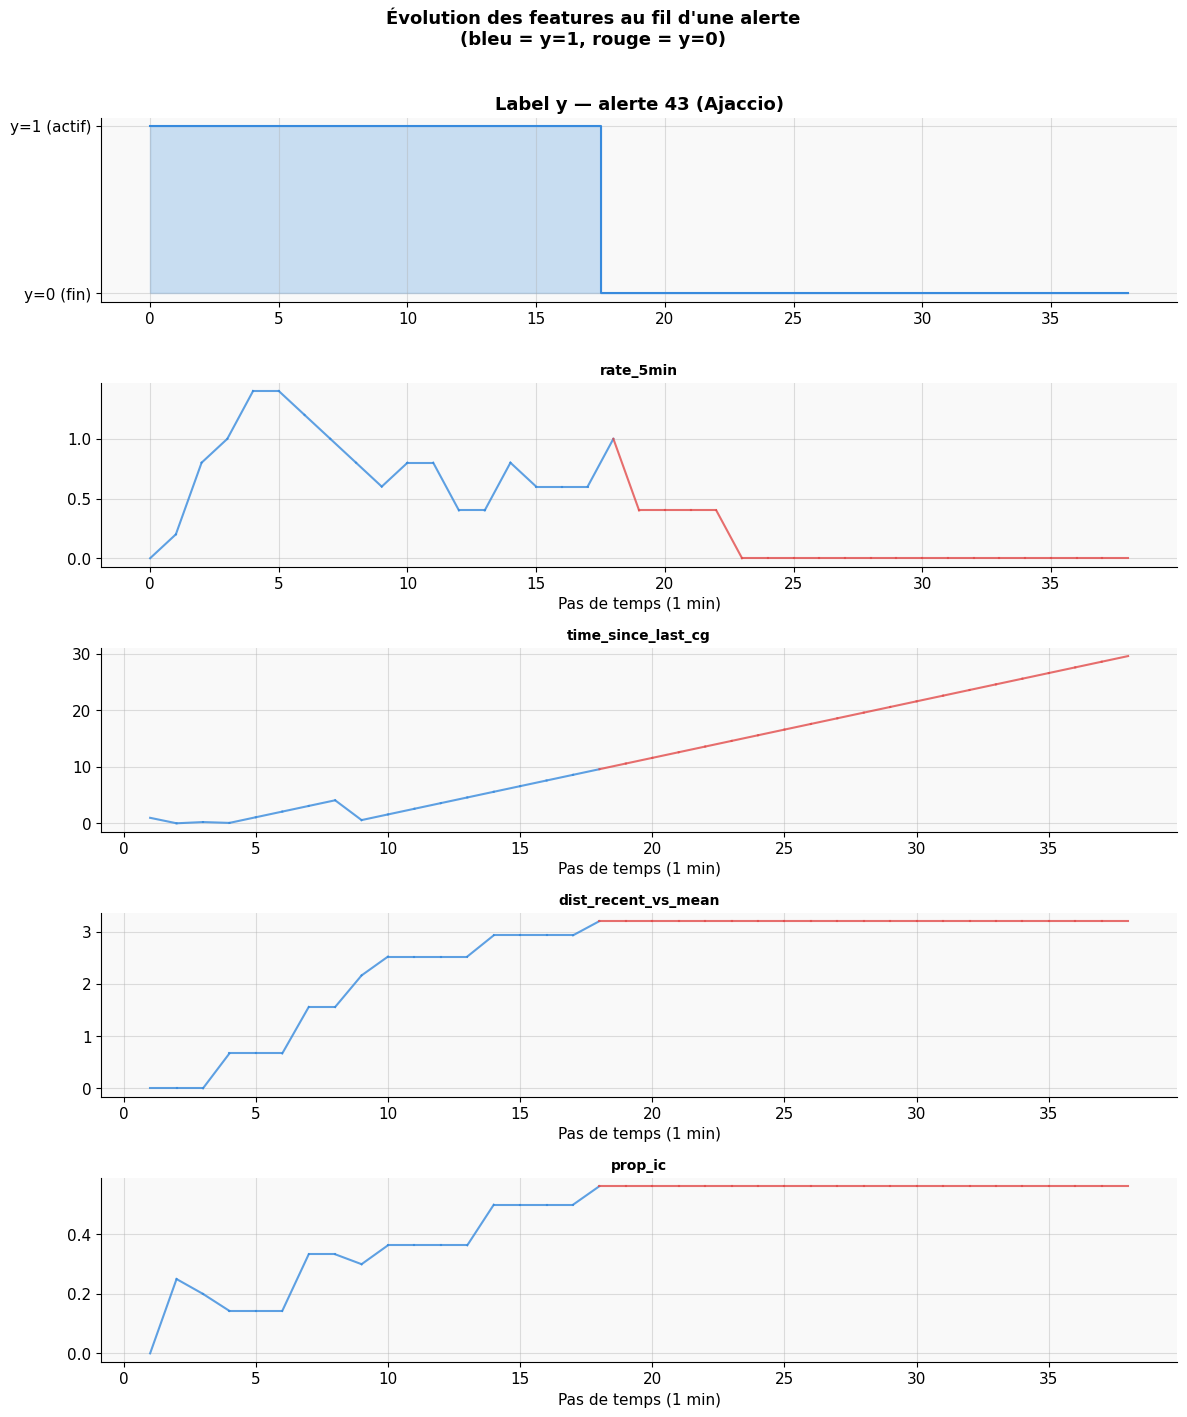

In [23]:
if ds is not None:
    # ── Évolution des features au fil d'une alerte ─────────────────────────────
    # On choisit une alerte représentative (durée médiane)
    alert_sizes = ds.groupby(['airport', 'airport_alert_id']).size()
    median_size = alert_sizes.median()
    best_alert = alert_sizes[np.abs(alert_sizes - median_size) ==
                              np.abs(alert_sizes - median_size).min()].index[0]

    ex = ds[(ds['airport'] == best_alert[0]) &
            (ds['airport_alert_id'] == best_alert[1])].copy()
    ex = ex.sort_values('time').reset_index(drop=True)
    t = np.arange(len(ex))

    feats_to_plot = ['rate_5min', 'time_since_last_cg', 'dist_recent_vs_mean', 'prop_ic']
    feats_to_plot = [f for f in feats_to_plot if f in ex.columns]

    fig, axes = plt.subplots(len(feats_to_plot) + 1, 1, figsize=(12, 3.5*len(feats_to_plot)))

    # Label y en fond
    axes[0].fill_between(t, ex['y'], alpha=0.25, color=PALETTE['y1'], step='mid')
    axes[0].step(t, ex['y'], where='mid', color=PALETTE['y1'], lw=1.5)
    axes[0].set_yticks([0, 1])
    axes[0].set_yticklabels(['y=0 (fin)', 'y=1 (actif)'])
    axes[0].set_title(f'Label y — alerte {best_alert[1]} ({best_alert[0]})')

    for ax, feat in zip(axes[1:], feats_to_plot):
        vals = ex[feat].values
        # colorier selon y
        for i in range(len(t) - 1):
            color = PALETTE['y1'] if ex['y'].iloc[i] == 1 else PALETTE['y0']
            ax.plot(t[i:i+2], vals[i:i+2], color=color, lw=1.5, alpha=0.8)
        ax.set_title(feat, fontsize=10)
        ax.set_xlabel('Pas de temps (1 min)')

    plt.suptitle('Évolution des features au fil d\'une alerte\n(bleu = y=1, rouge = y=0)',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

---
## 7. Trade-off opérationnel — seuil vs gain vs erreur

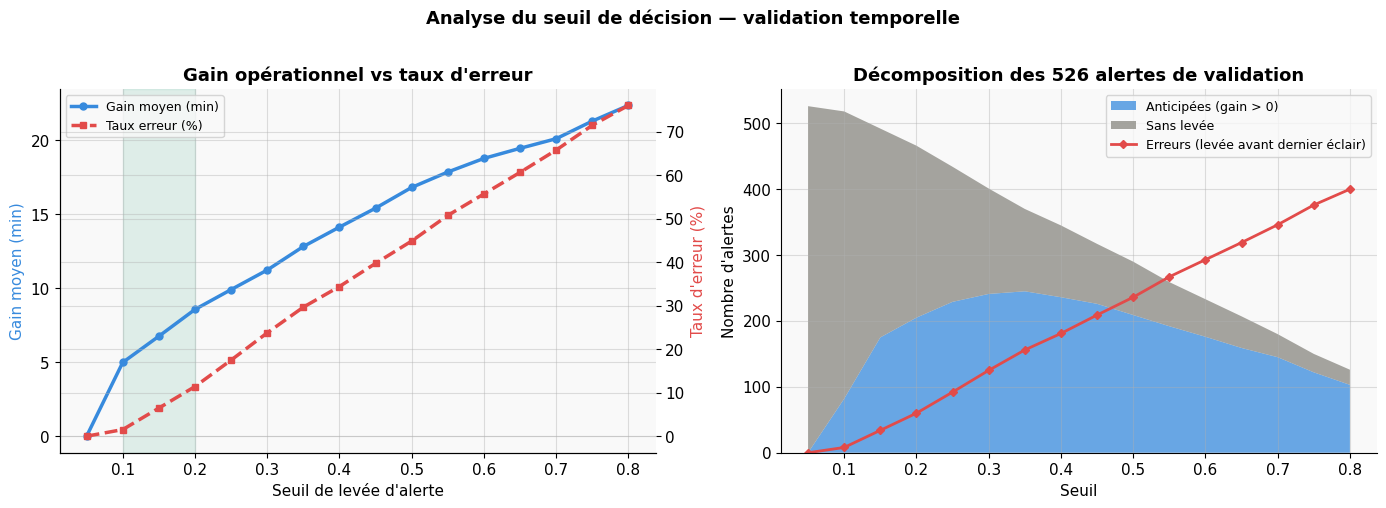

 seuil  gain_moyen  taux_erreur  nb_alertes_anticipees  nb_sans_levee  nb_erreurs
  0.05        0.00       0.0000                      0            526           0
  0.10        4.98       0.0152                     82            436           8
  0.15        6.75       0.0646                    175            317          34
  0.20        8.56       0.1141                    205            261          60
  0.25        9.90       0.1749                    229            205          92
  0.30       11.22       0.2376                    241            160         125
  0.35       12.81       0.2966                    245            125         156
  0.40       14.12       0.3441                    236            109         181
  0.45       15.40       0.3973                    226             91         209
  0.50       16.80       0.4487                    209             81         236
  0.55       17.84       0.5076                    192             67         267
  0.60       18.

In [24]:
# Résultats du notebook clean_model (section 10)
df_resultats = pd.DataFrame({
    'seuil':                 [0.05,0.10,0.15,0.20,0.25,0.30,0.35,0.40,
                               0.45,0.50,0.55,0.60,0.65,0.70,0.75,0.80],
    'gain_moyen':            [0.0,4.98,6.75,8.56,9.90,11.22,12.81,14.12,
                               15.40,16.80,17.84,18.76,19.44,20.09,21.28,22.34],
    'taux_erreur':           [0.0,0.0152,0.0646,0.1141,0.1749,0.2376,0.2966,0.3441,
                               0.3973,0.4487,0.5076,0.5570,0.6065,0.6578,0.7148,0.7605],
    'nb_alertes_anticipees': [0,82,175,205,229,241,245,236,226,209,192,176,159,145,122,103],
    'nb_sans_levee':         [526,436,317,261,205,160,125,109,91,81,67,57,48,35,28,23],
    'nb_erreurs':            [0,8,34,60,92,125,156,181,209,236,267,293,319,346,376,400],
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gain vs taux erreur
ax1 = axes[0]
ax2 = ax1.twinx()
l1 = ax1.plot(df_resultats['seuil'], df_resultats['gain_moyen'],
               color=PALETTE['y1'], lw=2.5, marker='o', ms=5, label='Gain moyen (min)')
l2 = ax2.plot(df_resultats['seuil'], df_resultats['taux_erreur'] * 100,
               color=PALETTE['y0'], lw=2.5, marker='s', ms=5, ls='--', label='Taux erreur (%)')
ax1.axvspan(0.10, 0.20, alpha=0.12, color='#1D9E75', label='Zone sweet-spot')
ax1.set_xlabel('Seuil de levée d\'alerte')
ax1.set_ylabel('Gain moyen (min)', color=PALETTE['y1'])
ax2.set_ylabel('Taux d\'erreur (%)', color=PALETTE['y0'])
lines = l1 + l2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', fontsize=9)
ax1.set_title('Gain opérationnel vs taux d\'erreur')

# Alertes anticipées vs sans levée
ax = axes[1]
ax.stackplot(df_resultats['seuil'],
             df_resultats['nb_alertes_anticipees'],
             df_resultats['nb_sans_levee'],
             labels=['Anticipées (gain > 0)', 'Sans levée'],
             colors=[PALETTE['y1'], PALETTE['neutral']],
             alpha=0.75)
ax.plot(df_resultats['seuil'], df_resultats['nb_erreurs'],
        color=PALETTE['y0'], lw=2, marker='D', ms=4, label='Erreurs (levée avant dernier éclair)')
ax.set_xlabel('Seuil')
ax.set_ylabel('Nombre d\'alertes')
ax.set_title('Décomposition des 526 alertes de validation')
ax.legend(fontsize=9)

plt.suptitle('Analyse du seuil de décision — validation temporelle',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(df_resultats.to_string(index=False))

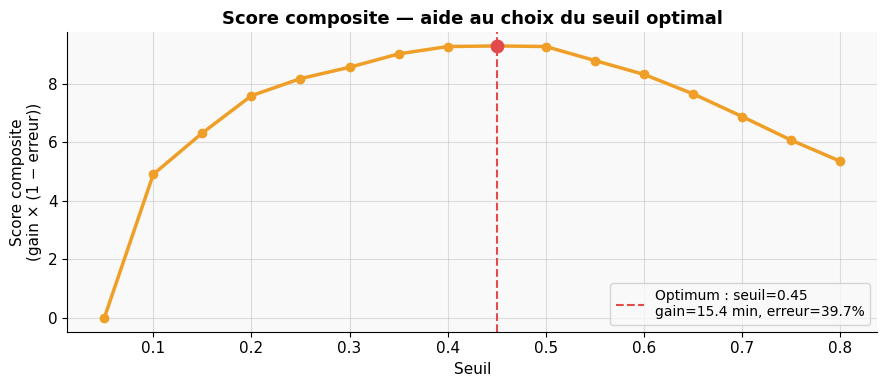

In [25]:
# ── Score composite : gain_moyen × (1 - taux_erreur) ──────────────────────────
df_resultats['score_composite'] = df_resultats['gain_moyen'] * (1 - df_resultats['taux_erreur'])

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(df_resultats['seuil'], df_resultats['score_composite'],
        color='#EF9F27', lw=2.5, marker='o', ms=6)
best_idx = df_resultats['score_composite'].idxmax()
best_row = df_resultats.loc[best_idx]
ax.axvline(best_row['seuil'], color='#E24B4A', lw=1.5, ls='--',
           label=f"Optimum : seuil={best_row['seuil']:.2f}\n"
                 f"gain={best_row['gain_moyen']:.1f} min, erreur={100*best_row['taux_erreur']:.1f}%")
ax.scatter([best_row['seuil']], [best_row['score_composite']],
           color='#E24B4A', s=80, zorder=5)
ax.set_xlabel('Seuil')
ax.set_ylabel('Score composite\n(gain × (1 − erreur))')
ax.set_title('Score composite — aide au choix du seuil optimal')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

---
## 8. Synthèse

| Famille | Features clés | Lien avec les perf. modèle |
|---|---|---|
| **Récence CG** | `time_since_last_cg`, `time_since_last` | Top gain XGBoost — le silence CG est le signal le plus fort |
| **Activité récente** | `rate_5min`, `strike_count_30min` | Fortement corrélé à y — activité nulle = fin probable |
| **Inter-arrivées** | `max_interarrival`, `deceleration` | Capte les pauses longues que les rates ne voient pas |
| **Spatiales** | `dist_recent_vs_mean`, `trend_dist` | Signal secondaire : orage qui s'éloigne |
| **Physiques** | `amplitude_trend`, `ic_ratio_trend` | Faiblit en fin d'orage — signal utile mais bruité |
| **Cycliques** | `month_sin/cos`, `hour_sin/cos` | Contextualise la probabilité de base (faible en hiver) |

**Trade-off seuil** : le sweet-spot opérationnel se situe autour de **seuil = 0.10–0.15** qui offre ~5–7 min de gain anticipé pour un taux d'erreur contenu sous 7 %.

**Limites identifiées** :
- La classe `y=0` (25 %) est plus difficile — recall 0.67 vs 0.91 pour y=1
- Les alertes longues (> 1h) sont rares mais concentrent les erreurs
- Le filtrage Pise 2016 réduit l'hétérogénéité du jeu d'entraînement sur cet aéroport